In [1]:
import pandas as pd 
agenda_watch_df = pd.read_csv('../data/agenda-watch-bay-area-202027.csv', index_col=0)

<AxesSubplot:>

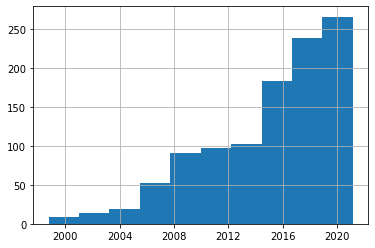

In [5]:
pd.to_datetime(agenda_watch_df['date']).hist()

# Debug

In [8]:
import subprocess

In [6]:
service_url = 'https://singlefile-webapp-ukvxfz3sya-uc.a.run.app'
url = 'https://web.archive.org/web/20140325112710/http://www.sfchronicle.com/'

In [15]:
SINGLEFILE_EXECUTABLE = 'single-file'
BROWSER_PATH = '/opt/homebrew/bin/chromium'
BROWSER_ARGS = '["--no-sandbox"]'
cmd = [
        SINGLEFILE_EXECUTABLE,
        '--browser-executable-path=' + BROWSER_PATH,
#         "--browser-args='%s'" % BROWSER_ARGS,
        url,
        "--block-images",
        '--dump-content',
    ]
p = subprocess.Popen(cmd, stdout=subprocess.PIPE)

In [24]:
import sys

In [27]:
sys.path.insert(0, '../scripts-homepage-data/')

In [28]:
import get_bounding_boxes_from_html as bb

In [109]:
page, browser, playwright = await bb.instantiate_new_page_object(headless=False, block_images=False, block_external_files=False)

/Users/spangher/Projects/usc-research/newsworthiness/notebooks/../scripts-homepage-data/get_bounding_boxes_from_html.py:493: RuntimeWarning: coroutine 'Browser.new_context' was never awaited
  """


In [41]:
from pathlib import Path
import typing

In [53]:
await page.add_init_script(path="../scripts-homepage-data/js/single-file-bootstrap.js")
await page.add_init_script(path="../scripts-homepage-data/js/single-file-hooks-frames.js")
await page.add_init_script(path="../scripts-homepage-data/js/single-file-frames.js")

In [60]:
await page.goto('https://web.archive.org/web/20140325112710/http://www.sfchronicle.com/')

<Response url='https://web.archive.org/web/20140325112710/http://www.sfchronicle.com/' request=<Request url='https://web.archive.org/web/20140325112710/http://www.sfchronicle.com/' method='GET'>>

In [61]:
await page.evaluate(open("../scripts-homepage-data/js/single-file.js").read())
page_content = await page.evaluate(
    """
        () => singlefile.getPageData({
                removeHiddenElements: true,
                removeUnusedStyles: true,
                removeUnusedFonts: true,
                removeImports: true,
                blockScripts: false,
                blockAudios: true,
                blockVideos: true,
                blockImages: true,
                compressHTML: false,
                removeAlternativeFonts: true,
                removeAlternativeMedias: true,
                removeAlternativeImages: true,
                groupDuplicateImages: true
        });
    """
)
page_html_content = page_content.get("content")

In [62]:
with open('test.html', 'w') as f:
    f.write(page_html_content)

In [75]:
import requests
import time

In [87]:
now = time.time()

local_api_url = 'http://localhost:8080'
api_url = 'https://singlefile-webapp-playwright-1-ukvxfz3sya-uc.a.run.app'

t = requests.post(
    api_url,
    headers={'Content-Type': 'application/x-www-form-urlencoded'}, 
    data={'url': 'https://web.archive.org/web/20140325112710/http://www.sfchronicle.com/'}
)

print(time.time() - now)

31.3736789226532


In [82]:
with open('test.html', 'w') as f:
    f.write(t.text)

In [83]:
! open test.html

In [89]:
import random

In [90]:
import itertools

In [96]:
c = itertools.cycle([1,2,3])

In [ ]:
list(map(lambda x: next(c), range(1000)))

In [112]:
import os 

In [120]:
f = 'file://' + os.getcwd() + '/../scripts-homepage-data/scrape_using_gcr/index.html'

In [122]:
one_file_bbs = await bb.get_bounding_box_one_file(file=f)

In [129]:
from bs4 import BeautifulSoup

In [130]:
soup = BeautifulSoup(html_str)

In [128]:
html_str = open('../scripts-homepage-data/scrape_using_gcr/index.html').read()

In [ ]:
one_file_bbs['bounding_boxes']